# Data Profiling — MUSAN Dataset
Proyecto C: Audio Source Separation via NMF
**Optimización Numérica | Iberoamericana León 2026**

---
Ejecutar localmente con Jupyter.  
Los outputs (PNG + CSV) se suben a GitHub en la carpeta `outputs/`.

In [1]:
# ─────────────────────────────────────────────────────────────────
#  ▼  ÚNICA CELDA QUE NECESITAS EDITAR  ▼
# ─────────────────────────────────────────────────────────────────

DATA_ROOT   = r'D:\Optimizacion_proyecto\nmf-audio-separation\data'
OUTPUT_DIR  = r'D:\Optimizacion_proyecto\nmf-audio-separation\outputs'

# Cuántos archivos analizar por categoría (None = todos)
# Con 30 es suficiente para el EDA; aumenta si quieres más estadístico
N_PER_CAT   = 30 

# Parámetros STFT (no cambiar para que coincidan con el modelo)
N_FFT       = 1024
HOP_LENGTH  = 512
SR_TARGET   = 22050

# ─────────────────────────────────────────────────────────────────

import os
from pathlib import Path

os.makedirs(OUTPUT_DIR, exist_ok=True)
CATEGORIES = ['music', 'noise', 'speech']

print(f'Datos  : {DATA_ROOT}')
print(f'Outputs: {OUTPUT_DIR}\n')

total = 0
for cat in CATEGORIES:
    p = Path(DATA_ROOT) / cat
    if p.exists():
        wavs = list(p.rglob('*.wav')) + list(p.rglob('*.flac'))
        mb   = sum(f.stat().st_size for f in wavs) / 1e6
        print(f'  {cat:8s}  {len(wavs):>6,} archivos   {mb:>8.1f} MB')
        total += len(wavs)
    else:
        print(f'  {cat:8s}  ❌ carpeta no encontrada: {p}')
print(f'  {"─"*42}')
print(f'  {"TOTAL":8s}  {total:>6,} archivos')

Datos  : D:\Optimizacion_proyecto\nmf-audio-separation\data
Outputs: D:\Optimizacion_proyecto\nmf-audio-separation\outputs

  music        660 archivos     4909.2 MB
  noise        930 archivos      717.3 MB
  speech       426 archivos     6963.7 MB
  ──────────────────────────────────────────
  TOTAL      2,016 archivos


Celda 2 — Imports y funciones

In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import librosa
import librosa.display
import soundfile as sf
import warnings
from tqdm.notebook import tqdm
from pathlib import Path

warnings.filterwarnings('ignore')
np.random.seed(42)

PALETTE = {
    'music'  : '#4C72B0',
    'noise'  : '#DD8452',
    'speech' : '#55A868',
    'bg'     : '#F8F9FA',
    'grid'   : '#DEE2E6',
    'text'   : '#212529',
}
CAT_LABELS = {'music': 'Music', 'noise': 'Noise', 'speech': 'Speech'}

# ─────────────────────────────────────────────────────────────────

def scan_files(data_root, categories, n_per_cat=None, exts=('.wav','.flac','.mp3')):
    """Escanea carpetas y devuelve DataFrame con metadatos de archivos."""
    rows = []
    for cat in categories:
        path = Path(data_root) / cat
        if not path.exists():
            continue
        files = [f for f in path.rglob('*') if f.suffix.lower() in exts]
        if n_per_cat and len(files) > n_per_cat:
            rng = np.random.default_rng(42)
            idx = rng.choice(len(files), n_per_cat, replace=False)
            files = [files[i] for i in sorted(idx)]
        for f in files:
            rows.append({
                'category'   : cat,
                'path'       : str(f),
                'filename'   : f.name,
                'size_bytes' : f.stat().st_size,
                'subdir'     : str(f.parent.relative_to(path)),
            })
    return pd.DataFrame(rows)


def analyze_file(path, sr_target=SR_TARGET, max_dur=30.0):
    """Extrae características acústicas y de espectrograma de un archivo."""
    try:
        info = sf.info(path)
        y, sr = librosa.load(path, sr=sr_target, mono=True, duration=max_dur)
        S = np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH))
        return {
            'ok'                  : True,
            'sr_original'         : info.samplerate,
            'channels'            : info.channels,
            'duration_s'          : info.duration,
            'format'              : info.format,
            'rms_energy'          : float(np.sqrt(np.mean(y**2))),
            'zero_cross_rate'     : float(np.mean(librosa.feature.zero_crossing_rate(y))),
            'spectral_centroid_hz': float(np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))),
            'spectral_bandwidth'  : float(np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))),
            'spectral_rolloff_hz' : float(np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))),
            'stft_F'              : S.shape[0],
            'stft_T'              : S.shape[1],
            'stft_mean'           : float(S.mean()),
            'stft_max'            : float(S.max()),
        }
    except Exception as e:
        return {'ok': False, 'error': str(e)}


def ax_style(ax, title, xlabel='', ylabel=''):
    ax.set_facecolor(PALETTE['bg'])
    ax.set_title(title, fontsize=9.5, fontweight='bold', pad=6, color=PALETTE['text'])
    ax.set_xlabel(xlabel, fontsize=8, color='#495057')
    ax.set_ylabel(ylabel, fontsize=8, color='#495057')
    ax.tick_params(labelsize=7.5, colors='#495057')
    ax.grid(True, color=PALETTE['grid'], linewidth=0.5, alpha=0.8, zorder=0)
    for sp in ax.spines.values(): sp.set_edgecolor(PALETTE['grid'])

print('Imports y funciones listas')

Imports y funciones listas


Celda 3 — Escaneo y extracción de características

In [3]:
print(f'Escaneando (muestra: {N_PER_CAT} por categoría)...')
df_files = scan_files(DATA_ROOT, CATEGORIES, n_per_cat=N_PER_CAT)
print(f'   {len(df_files)} archivos seleccionados\n')

records = []
for _, row in tqdm(df_files.iterrows(), total=len(df_files), desc='Analizando'):
    meta = analyze_file(row['path'])
    meta.update(row.to_dict())
    records.append(meta)

df     = pd.DataFrame(records)
df_ok  = df[df['ok'] == True].copy()
errors = df[df['ok'] != True]

print(f'\n{len(df_ok)}/{len(df_files)} archivos OK')
if len(errors) > 0:
    print(f'{len(errors)} errores:')
    print(errors[['filename','error']].to_string(index=False))

df_ok.to_csv(f'{OUTPUT_DIR}/metadata_MUSAN.csv', index=False)
print(f'\n{OUTPUT_DIR}/metadata_MUSAN.csv')

df_ok[['category','filename','duration_s','sr_original',
       'rms_energy','spectral_centroid_hz','stft_F','stft_T']].head(6)

Escaneando (muestra: 30 por categoría)...
   90 archivos seleccionados



Analizando:   0%|          | 0/90 [00:00<?, ?it/s]


90/90 archivos OK

D:\Optimizacion_proyecto\nmf-audio-separation\outputs/metadata_MUSAN.csv


,category,filename,duration_s,sr_original,rms_energy,spectral_centroid_hz,stft_F,stft_T
0,music,music-fma-0054.wav,279.170625,16000,0.133786,937.407722,513,1292
1,music,music-fma-0056.wav,338.573000,16000,0.126132,688.607348,513,1292
2,music,music-fma-0060.wav,133.433500,16000,0.132331,1238.405911,513,1292
3,music,music-fma-0083.wav,259.030000,16000,0.139785,722.752124,513,1292
4,music,music-fma-0119.wav,702.537000,16000,0.066273,1624.058486,513,1292
5,music,music-fma-wa-0000.wav,96.626937,16000,0.129934,921.465379,513,1292


 Celda 4 — Tabla resumen por categoría

In [4]:
summary = df_ok.groupby('category').agg(
    n_archivos          = ('filename',             'count'),
    dur_total_min       = ('duration_s',           lambda x: round(x.sum()/60, 2)),
    dur_media_s         = ('duration_s',           lambda x: round(x.mean(), 2)),
    dur_std_s           = ('duration_s',           lambda x: round(x.std(), 2)),
    dur_min_s           = ('duration_s',           lambda x: round(x.min(), 2)),
    dur_max_s           = ('duration_s',           lambda x: round(x.max(), 2)),
    sr_comun_hz         = ('sr_original',          lambda x: x.mode()[0]),
    canales             = ('channels',             lambda x: x.mode()[0]),
    rms_media           = ('rms_energy',           lambda x: round(x.mean(), 5)),
    zcr_media           = ('zero_cross_rate',      lambda x: round(x.mean(), 5)),
    centroide_hz        = ('spectral_centroid_hz', lambda x: round(x.mean(), 1)),
    bandwidth_hz        = ('spectral_bandwidth',   lambda x: round(x.mean(), 1)),
    rolloff_hz          = ('spectral_rolloff_hz',  lambda x: round(x.mean(), 1)),
    stft_F              = ('stft_F',               'first'),
    stft_T_media        = ('stft_T',               lambda x: round(x.mean())),
    tamano_MB           = ('size_bytes',           lambda x: round(x.sum()/1e6, 1)),
)

summary.to_csv(f'{OUTPUT_DIR}/summary_MUSAN.csv')

print('=' * 62)
print('  RESUMEN ESTRUCTURAL — MUSAN Dataset')
print('=' * 62)
print(summary.T.to_string())
print('=' * 62)
print(f'\n{OUTPUT_DIR}/summary_MUSAN.csv')

  RESUMEN ESTRUCTURAL — MUSAN Dataset
category             music        noise       speech
n_archivos        30.00000     30.00000     30.00000
dur_total_min    100.61000      8.10000    272.66000
dur_media_s      201.23000     16.20000    545.32000
dur_std_s        116.80000     18.00000    157.07000
dur_min_s         81.87000      0.81000    126.12000
dur_max_s        702.54000     76.17000    784.04000
sr_comun_hz    16000.00000  16000.00000  16000.00000
canales            1.00000      1.00000      1.00000
rms_media          0.15369      0.11740      0.09353
zcr_media          0.06806      0.13536      0.08699
centroide_hz    1309.70000   2132.30000   1373.60000
bandwidth_hz    1391.70000   1845.30000   1165.10000
rolloff_hz      2637.00000   4118.70000   2547.80000
stft_F           513.00000    513.00000    513.00000
stft_T_media    1292.00000    568.00000   1292.00000
tamano_MB        193.20000     15.60000    523.50000

D:\Optimizacion_proyecto\nmf-audio-separation\outputs/summar

Celda 5 — Figura 1: Perfilamiento Estructural
> Figura principal para la **exposición del 13/04**

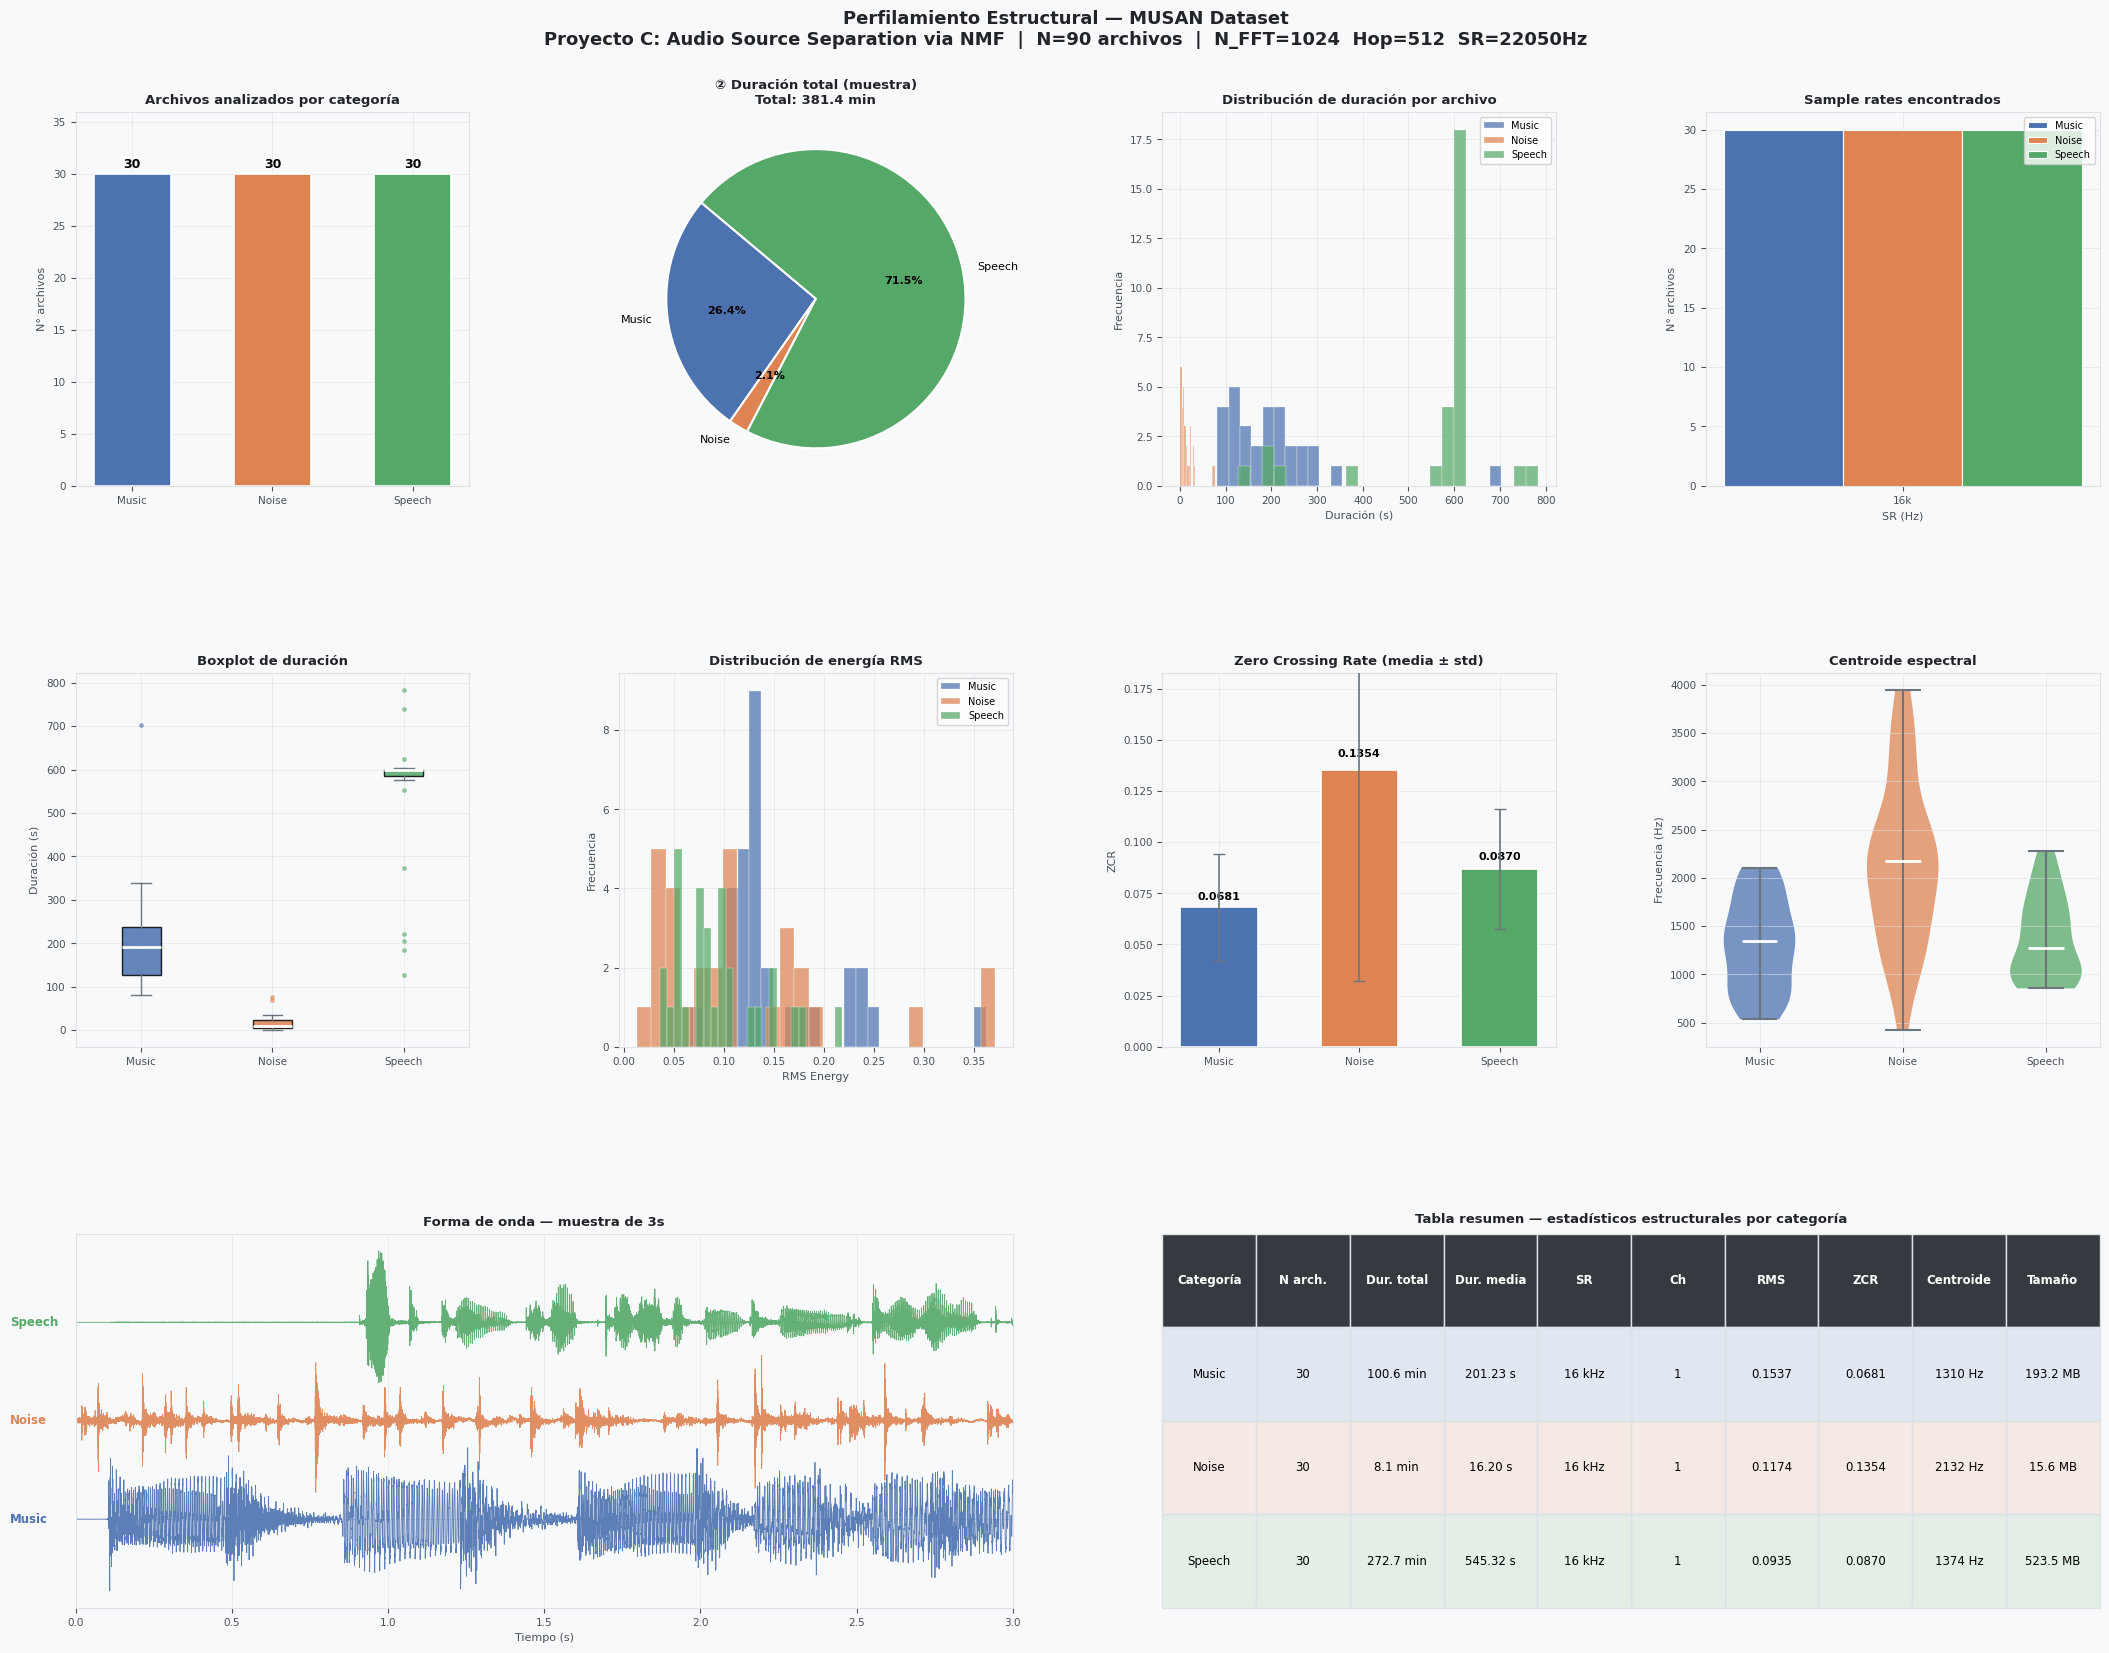

 D:\Optimizacion_proyecto\nmf-audio-separation\outputs/fig1_profiling_MUSAN.png


In [5]:
cats   = [c for c in CATEGORIES if c in df_ok['category'].unique()]
colors = [PALETTE[c] for c in cats]
labels = [CAT_LABELS[c] for c in cats]

fig = plt.figure(figsize=(22, 17), facecolor=PALETTE['bg'])
fig.suptitle(
    'Perfilamiento Estructural — MUSAN Dataset\n'
    f'Proyecto C: Audio Source Separation via NMF  |  '
    f'N={len(df_ok)} archivos  |  N_FFT={N_FFT}  Hop={HOP_LENGTH}  SR={SR_TARGET}Hz',
    fontsize=13, fontweight='bold', y=0.99, color=PALETTE['text']
)
gs = gridspec.GridSpec(3, 4, figure=fig,
                       hspace=0.50, wspace=0.38,
                       left=0.05, right=0.97, top=0.93, bottom=0.05)

# ── [0,0] Conteo de archivos ──────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
counts = [len(df_ok[df_ok['category']==c]) for c in cats]
bars = ax.bar(labels, counts, color=colors, edgecolor='white', lw=1.2, width=0.55, zorder=3)
for bar, v in zip(bars, counts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(counts)*0.01,
            f'{v:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax_style(ax, 'Archivos analizados por categoría', ylabel='N° archivos')
ax.set_ylim(0, max(counts)*1.20)

# ── [0,1] Pie duración total ──────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
dur_tot = [df_ok[df_ok['category']==c]['duration_s'].sum()/60 for c in cats]
wedges, texts, at = ax.pie(
    dur_tot, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5), textprops={'fontsize':8})
for a in at: a.set_fontsize(8); a.set_fontweight('bold')
ax.set_title(f'② Duración total (muestra)\nTotal: {sum(dur_tot):.1f} min',
             fontsize=9.5, fontweight='bold', pad=6, color=PALETTE['text'])
ax.set_facecolor(PALETTE['bg'])

# ── [0,2] Histograma duración ─────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
for cat, color, label in zip(cats, colors, labels):
    d = df_ok[df_ok['category']==cat]['duration_s'].dropna()
    ax.hist(d, bins=25, color=color, alpha=0.72, label=label,
            edgecolor='white', lw=0.3, zorder=3)
ax.legend(fontsize=7)
ax_style(ax, 'Distribución de duración por archivo', 'Duración (s)', 'Frecuencia')

# ── [0,3] Sample rates ────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 3])
sr_df  = df_ok.groupby(['category','sr_original']).size().reset_index(name='count')
sr_vals = sorted(sr_df['sr_original'].unique())
x, w = np.arange(len(sr_vals)), 0.25
for i, (cat, color, label) in enumerate(zip(cats, colors, labels)):
    sub = sr_df[sr_df['category']==cat]
    h   = [sub[sub['sr_original']==sr]['count'].sum()
           if sr in sub['sr_original'].values else 0 for sr in sr_vals]
    ax.bar(x+i*w, h, w, label=label, color=color, edgecolor='white', lw=0.8, zorder=3)
ax.set_xticks(x+w); ax.set_xticklabels([f'{int(sr/1000)}k' for sr in sr_vals], fontsize=7.5)
ax.legend(fontsize=7)
ax_style(ax, 'Sample rates encontrados', 'SR (Hz)', 'N° archivos')

# ── [1,0] Boxplot duración ────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
data_box = [df_ok[df_ok['category']==c]['duration_s'].dropna().values for c in cats]
bp = ax.boxplot(data_box, patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color='#6C757D'), capprops=dict(color='#6C757D'),
    flierprops=dict(marker='o', markersize=2.5, alpha=0.5))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.85)
for flier, color in zip(bp['fliers'], colors):
    flier.set_markerfacecolor(color); flier.set_markeredgecolor(color)
ax.set_xticklabels(labels, fontsize=8)
ax_style(ax, 'Boxplot de duración', ylabel='Duración (s)')

# ── [1,1] RMS Energy ─────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
for cat, color, label in zip(cats, colors, labels):
    d = df_ok[df_ok['category']==cat]['rms_energy'].dropna()
    ax.hist(d, bins=25, color=color, alpha=0.72, label=label,
            edgecolor='white', lw=0.3, zorder=3)
ax.legend(fontsize=7)
ax_style(ax, 'Distribución de energía RMS', 'RMS Energy', 'Frecuencia')

# ── [1,2] Zero Crossing Rate ──────────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
means_zcr = [df_ok[df_ok['category']==c]['zero_cross_rate'].mean() for c in cats]
stds_zcr  = [df_ok[df_ok['category']==c]['zero_cross_rate'].std()  for c in cats]
bars = ax.bar(labels, means_zcr, color=colors, edgecolor='white', lw=1.2,
              width=0.55, yerr=stds_zcr, capsize=4,
              error_kw={'ecolor':'#6C757D','lw':1.2}, zorder=3)
for bar, v in zip(bars, means_zcr):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.04,
            f'{v:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax_style(ax, 'Zero Crossing Rate (media ± std)', ylabel='ZCR')
ax.set_ylim(0, max(means_zcr)*1.35)

# ── [1,3] Centroide espectral (violín) ────────────────────────────
ax = fig.add_subplot(gs[1, 3])
vdata = [df_ok[df_ok['category']==c]['spectral_centroid_hz'].dropna().values for c in cats]
vp = ax.violinplot(vdata, positions=range(len(cats)), showmedians=True)
for pc, color in zip(vp['bodies'], colors):
    pc.set_facecolor(color); pc.set_alpha(0.75)
vp['cmedians'].set_color('white'); vp['cmedians'].set_linewidth(2)
for key in ('cmins','cmaxes','cbars'): vp[key].set_color('#6C757D')
ax.set_xticks(range(len(cats))); ax.set_xticklabels(labels, fontsize=8)
ax_style(ax, 'Centroide espectral', ylabel='Frecuencia (Hz)')

# ── [2,0-1] Formas de onda de muestra ────────────────────────────
ax = fig.add_subplot(gs[2, 0:2])
offset = 0.0
for cat, color, label in zip(cats, colors, labels):
    path = df_ok[df_ok['category']==cat]['path'].iloc[0]
    y, _ = librosa.load(path, sr=SR_TARGET, mono=True, duration=3.0)
    y    = y / (np.max(np.abs(y)) + 1e-8) * 0.4
    t    = np.linspace(0, len(y)/SR_TARGET, len(y))
    ax.plot(t, y + offset, color=color, lw=0.6, alpha=0.9)
    ax.axhline(offset, color=color, lw=0.4, ls='--', alpha=0.4)
    ax.text(-0.07, offset, label, transform=ax.get_yaxis_transform(),
            fontsize=8.5, fontweight='bold', color=color, va='center')
    offset += 0.55
ax.set_yticks([]); ax.set_xlim(0, 3.0)
ax.set_facecolor('#F0F2F5')
ax_style(ax, 'Forma de onda — muestra de 3s', 'Tiempo (s)')

# ── [2,2-3] Tabla resumen ─────────────────────────────────────────
ax = fig.add_subplot(gs[2, 2:4])
ax.axis('off')
rows_tbl = []
for cat in cats:
    sub = df_ok[df_ok['category']==cat]
    rows_tbl.append([
        CAT_LABELS[cat],
        f"{len(sub):,}",
        f"{sub['duration_s'].sum()/60:.1f} min",
        f"{sub['duration_s'].mean():.2f} s",
        f"{int(sub['sr_original'].mode()[0]/1000)} kHz",
        f"{int(sub['channels'].mode()[0])}",
        f"{sub['rms_energy'].mean():.4f}",
        f"{sub['zero_cross_rate'].mean():.4f}",
        f"{sub['spectral_centroid_hz'].mean():.0f} Hz",
        f"{sub['size_bytes'].sum()/1e6:.1f} MB",
    ])
col_labels = ['Categoría','N arch.','Dur. total','Dur. media',
              'SR','Ch','RMS','ZCR','Centroide','Tamaño']
tbl = ax.table(cellText=rows_tbl, colLabels=col_labels,
               cellLoc='center', loc='center', bbox=[0,0,1,1])
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5)
for (r,c), cell in tbl.get_celld().items():
    cell.set_edgecolor(PALETTE['grid'])
    if r == 0:
        cell.set_facecolor('#343A40'); cell.get_text().set_color('white')
        cell.get_text().set_fontweight('bold')
    else:
        cell.set_facecolor(colors[r-1] + '22')
ax.set_title('Tabla resumen — estadísticos estructurales por categoría',
             fontsize=9.5, fontweight='bold', pad=8, color=PALETTE['text'])

out1 = f"{OUTPUT_DIR}/fig1_profiling_MUSAN.png"
fig.savefig(out1, dpi=180, bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()
print(f' {out1}')

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.gridspec import GridSpec
import librosa

# Configuración de estilo mejorada
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)
cats = [c for c in CATEGORIES if c in df_ok['category'].unique()]
colors = [PALETTE[c] for c in cats]
labels = [CAT_LABELS[c] for c in cats]

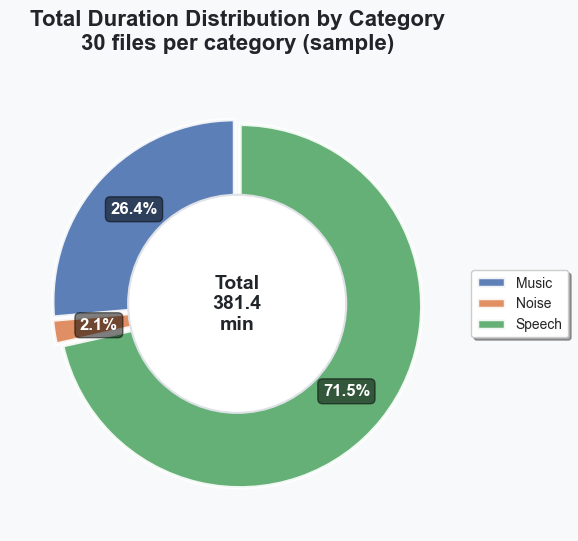

In [7]:
# ============================================================
# FIGURA 1: GRÁFICA DE PASTEL MEJORADA - CORREGIDA
# ============================================================

Categorias_limpias = ['Music', 'Noise', 'Speech']

fig1, ax = plt.subplots(figsize=(6, 6), facecolor=PALETTE['bg'])
fig1.patch.set_facecolor(PALETTE['bg'])

dur_tot = [df_ok[df_ok['category']==c]['duration_s'].sum()/60 for c in cats]

# Pie chart mejorado
wedges, texts, autotexts = ax.pie(
    dur_tot, 
    labels=None,
    colors=colors, 
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2.5, alpha=0.9),
    textprops={'fontsize': 11, 'fontweight': 'bold'},
    pctdistance=0.75,
    explode=[0.02] * len(cats)
)

# Mejorar porcentajes
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')
    autotext.set_bbox(dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.5))

# Círculo central
centre_circle = plt.Circle((0, 0), 0.60, fc='white', edgecolor=PALETTE['grid'], linewidth=1.5)
ax.add_artist(centre_circle)

# Texto central
ax.text(0, 0, f'Total\n{sum(dur_tot):.1f}\nmin', 
        ha='center', va='center',
          fontsize=14, fontweight='bold', 
        color=PALETTE['text'])
# Leyenda de cada categoría de Categorias_limpias
ax.legend(wedges, [Categoria for Categoria in Categorias_limpias],
          loc='center left', bbox_to_anchor=(1, 0.5),
          fontsize=10, frameon=True, fancybox=True, shadow=True)


ax.set_title('Total Duration Distribution by Category\n' + 
             '30 files per category (sample)', 
             fontsize=16, fontweight='bold', pad=20, color=PALETTE['text'])

plt.tight_layout()
fig1.savefig(f"{OUTPUT_DIR}/fig_pie_duracion_mejorada.png", dpi=300, bbox_inches='tight', 
             facecolor=PALETTE['bg'])
plt.show()

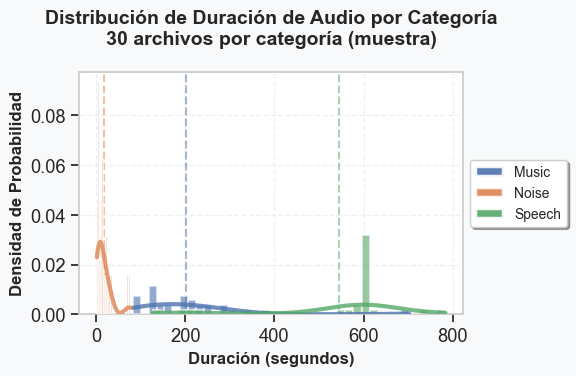

In [8]:
# ============================================================
# FIGURA 2: DISTRIBUCIÓN DE SONIDO - Histograma de duración
# ============================================================
fig2, ax = plt.subplots(figsize=(6, 4), facecolor=PALETTE['bg'])

# Histograma mejorado con KDE
for cat, color, label in zip(cats, colors, labels):
    d = df_ok[df_ok['category']==cat]['duration_s'].dropna()
    
    # Histograma con transparencia y borde
    ax.hist(d, bins=35, color=color, alpha=0.6, label=label,
            edgecolor='white', lw=1.5, density=True, zorder=3)
    
    # Añadir KDE (Kernel Density Estimation)
    from scipy import stats
    kde = stats.gaussian_kde(d)
    x_range = np.linspace(d.min(), d.max(), 200)
    ax.plot(x_range, kde(x_range), color=color, lw=3, alpha=0.8, zorder=4)

# Añadir líneas de referencia para la media
for cat, color in zip(cats, colors):
    mean_val = df_ok[df_ok['category']==cat]['duration_s'].mean()
    ax.axvline(mean_val, color=color, linestyle='--', lw=1.5, alpha=0.5)

# Mejoras visuales
ax.grid(True, alpha=0.3, linestyle='--', zorder=0)
ax.set_xlabel('Duración (segundos)', fontsize=12, fontweight='bold')
ax.set_ylabel('Densidad de Probabilidad', fontsize=12, fontweight='bold')
ax.set_title('Distribución de Duración de Audio por Categoría\n' +
             '30 archivos por categoría (muestra)', 
             fontsize=14, fontweight='bold', pad=20)

ax.legend(wedges, [Categoria for Categoria in Categorias_limpias],
          loc='center left', bbox_to_anchor=(1, 0.5),
          fontsize=10, frameon=True, fancybox=True, shadow=True)

# Leyenda de estadísticas

plt.tight_layout()
fig2.savefig(f"{OUTPUT_DIR}/fig_distribucion_sonido.png", dpi=300, 
             bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()

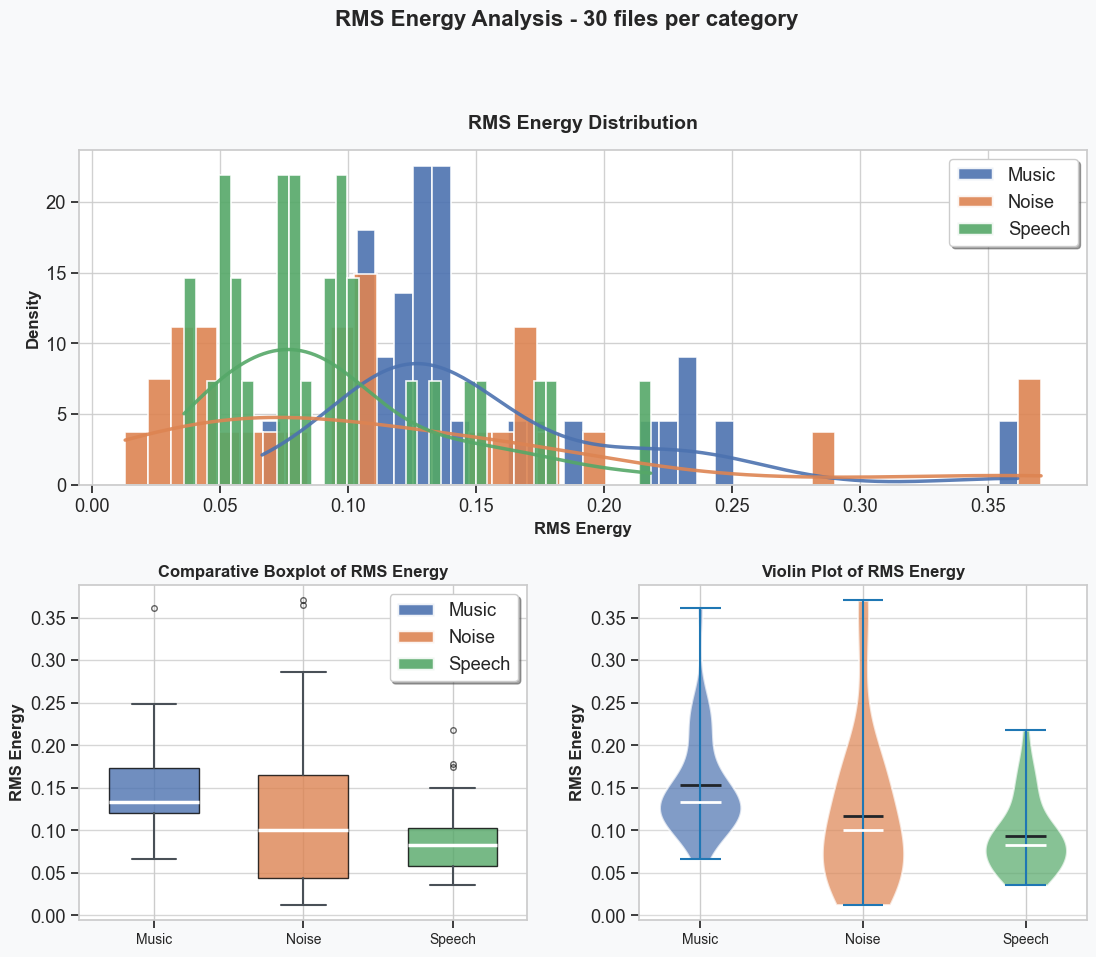

In [9]:
# ============================================================
# FIGURA 3: DISTRIBUCIÓN DE ENERGÍA RMS MEJORADA
# ============================================================
fig3 = plt.figure(figsize=(13, 10), facecolor=PALETTE['bg'])
gs = GridSpec(2, 2, figure=fig3, hspace=0.3, wspace=0.25)

# 3.1 Histograma RMS con KDE
ax1 = fig3.add_subplot(gs[0, :])
for cat, color, label in zip(cats, colors, labels):
    d = df_ok[df_ok['category']==cat]['rms_energy'].dropna()
    
    # Histograma
    ax1.hist(d, bins=40, color=color, alpha=0.9, label=label,
             edgecolor='white', lw=1.2, density=True)
    
    # KDE
    kde = stats.gaussian_kde(d)
    x_range = np.linspace(d.min(), d.max(), 200)
    ax1.plot(x_range, kde(x_range), color=color, lw=2.5, alpha=0.9)

ax1.set_xlabel('RMS Energy', fontsize=12, fontweight='bold')
ax1.set_ylabel('Density', fontsize=12, fontweight='bold')
ax1.set_title('RMS Energy Distribution', 
              fontsize=14, fontweight='bold', pad=15)
ax1.legend(wedges, [Categoria for Categoria in Categorias_limpias],
           loc='upper right', frameon=True, fancybox=True, shadow=True)

ax1.grid(True, alpha=0.9)

# 3.2 Boxplot comparativo mejorado
ax2 = fig3.add_subplot(gs[1, 0])
rms_data = [df_ok[df_ok['category']==c]['rms_energy'].dropna().values for c in cats]

# Boxplot con estilo mejorado
bp = ax2.boxplot(rms_data, patch_artist=True, widths=0.6,
                 medianprops=dict(color='white', linewidth=2.5),
                 whiskerprops=dict(color='#495057', linewidth=1.5),
                 capprops=dict(color='#495057', linewidth=1.5),
                 flierprops=dict(marker='o', markersize=4, alpha=0.6))

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax2.set_xticks(range(1, len(cats)+1))
ax2.set_xticklabels(labels, fontsize=10)
ax2.set_ylabel('RMS Energy', fontsize=12, fontweight='bold')
ax2.set_title('Comparative Boxplot of RMS Energy', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.8, axis='y')

# Poner las categorías en la leyenda
ax2.legend(wedges, [Categoria for Categoria in Categorias_limpias],
              loc='upper right', frameon=True, fancybox=True, shadow=True)

# 3.3 Violin plot para RMS
ax3 = fig3.add_subplot(gs[1, 1])
vp = ax3.violinplot(rms_data, positions=range(len(cats)), 
                    showmeans=True, showmedians=True)

for i, (pc, color) in enumerate(zip(vp['bodies'], colors)):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
    pc.set_edgecolor('white')
    pc.set_linewidth(1.5)

vp['cmeans'].set_color('#212529')
vp['cmeans'].set_linewidth(2)
vp['cmedians'].set_color('white')
vp['cmedians'].set_linewidth(2)

ax3.set_xticks(range(len(cats)))
ax3.set_xticklabels(labels, fontsize=10)
ax3.set_ylabel('RMS Energy', fontsize=12, fontweight='bold')
ax3.set_title('Violin Plot of RMS Energy', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.7, axis='y')

fig3.suptitle('RMS Energy Analysis - 30 files per category', 
              fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
fig3.savefig(f"{OUTPUT_DIR}/fig_energia_rms.png", dpi=300, 
             bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()




In [10]:
#!pip install resampy

⏳ Procesando Music... ✓ Completado
⏳ Procesando Noise... ✓ Completado
⏳ Procesando Speech... ✓ Completado


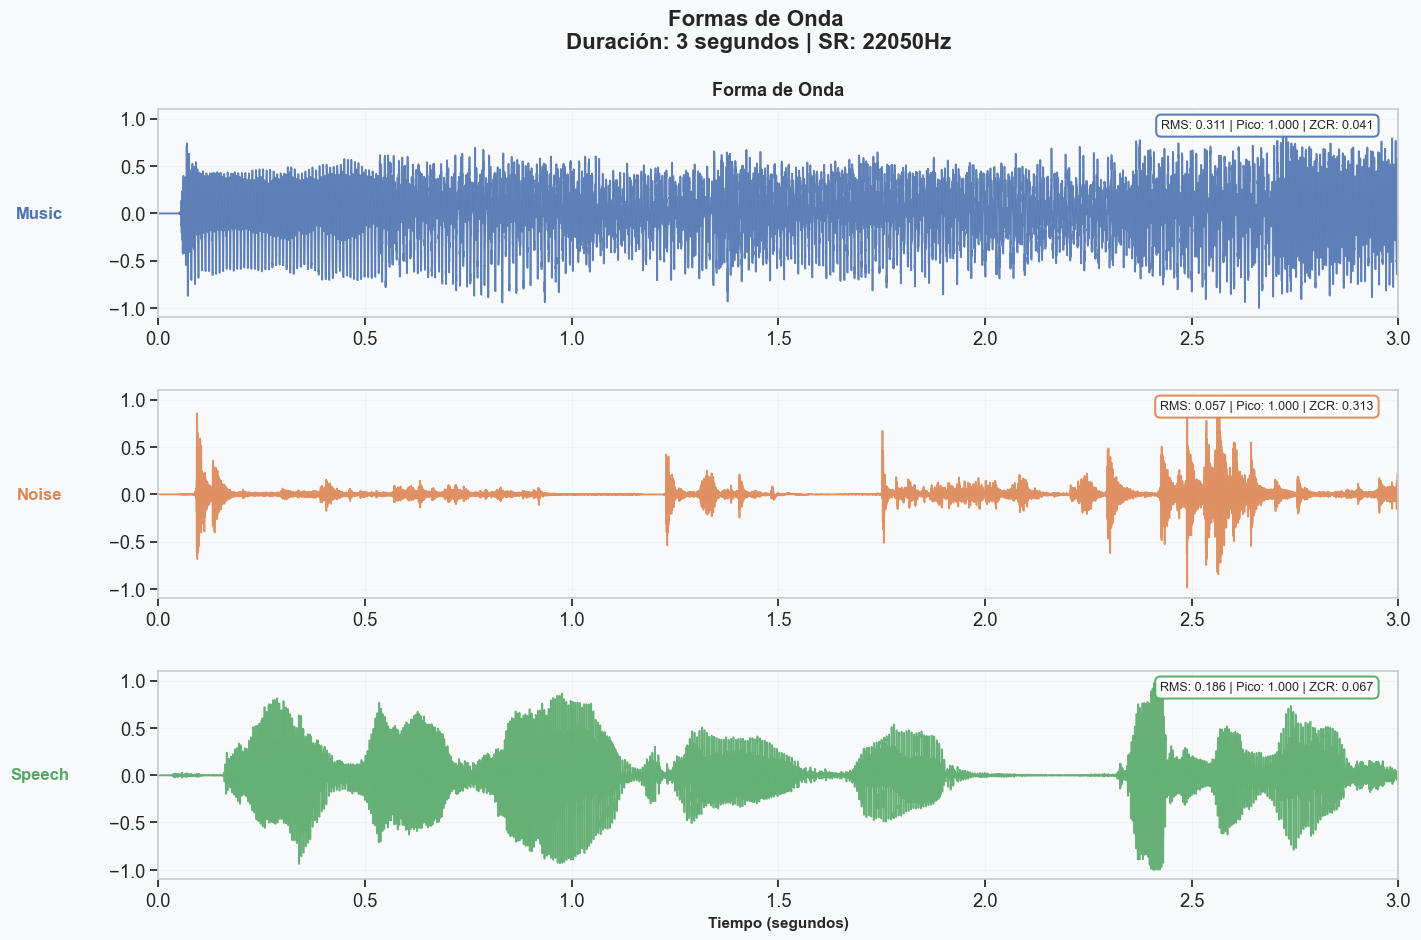

In [11]:
# ============================================================
# FIGURA 5: FORMAS DE ONDA - UNA MUESTRA POR CATEGORÍA (OPTIMIZADA)
# ============================================================
import librosa
import librosa.display
from scipy.signal import hilbert
import warnings
warnings.filterwarnings('ignore')

# Crear figura
fig5 = plt.figure(figsize=(16, 10), facecolor=PALETTE['bg'])

# Usar GridSpec para organizar: una fila por categoría, solo columna de waveform
gs = GridSpec(len(cats), 1, figure=fig5, hspace=0.35)

fig5.suptitle('Formas de Onda \n' +
              f'Duración: 3 segundos | SR: {SR_TARGET}Hz', 
              fontsize=16, fontweight='bold', y=0.98)

# Procesar una sola muestra por categoría
for idx, (cat, color, label) in enumerate(zip(cats, colors, labels)):
    
    print(f"⏳ Procesando {label}...", end=' ')
    
    # Crear subplot
    ax = fig5.add_subplot(gs[idx, 0])
    
    # ──────────────────────────────────────────────────────
    # Seleccionar UNA muestra representativa
    # ──────────────────────────────────────────────────────
    sub_df = df_ok[df_ok['category']==cat]
    
    # Estrategia rápida: tomar la muestra más cercana a la duración mediana
    median_dur = sub_df['duration_s'].median()
    
    # Encontrar el índice del archivo más cercano a la mediana (eficiente)
    idx_closest = (sub_df['duration_s'] - median_dur).abs().idxmin()
    sample_path = sub_df.loc[idx_closest, 'path']
    
    # ──────────────────────────────────────────────────────
    # Cargar y procesar audio (solo 3 segundos)
    # ──────────────────────────────────────────────────────
    try:
        # Cargar solo 3 segundos para ahorrar memoria y tiempo
        y, sr = librosa.load(sample_path, sr=SR_TARGET, mono=True, 
                            duration=3.0, res_type='kaiser_fast')  # resampling rápido
        
        # Normalizar
        y = y / (np.max(np.abs(y)) + 1e-8)
        t = np.linspace(0, len(y)/sr, len(y))
        
        # ──────────────────────────────────────────────────
        # Graficar forma de onda optimizada
        # ──────────────────────────────────────────────────
        
        # Señal principal (línea simple, más rápida)
        ax.plot(t, y, color=color, lw=1.2, alpha=0.85)
        
        # Envolvente de amplitud (usar método rápido)
        # Para mayor velocidad, usar promedio móvil en lugar de Hilbert
        window_size = int(0.01 * sr)  # Ventana de 10ms
        envelope = np.convolve(np.abs(y), np.ones(window_size)/window_size, mode='same')

        
        # Relleno simple (más rápido que fill_between condicional)
        ax.fill_between(t, y, 0, alpha=0.25, color=color)
        
        # ──────────────────────────────────────────────────
        # Decoración
        # ──────────────────────────────────────────────────
        ax.set_xlim(0, 3.0)
        ax.set_ylim(-1.1, 1.1)
        ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
        ax.set_facecolor('#F8F9FA')
        
        # Etiqueta de categoría en el eje Y
        ax.set_ylabel(label, fontsize=12, fontweight='bold', 
                     color=color, rotation=0, labelpad=50, va='center')
        
        # Título solo en el primer subplot
        if idx == 0:
            ax.set_title('Forma de Onda', fontsize=13, fontweight='bold', pad=10)
            ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
        
        # Etiqueta X solo en el último
        if idx == len(cats)-1:
            ax.set_xlabel('Tiempo (segundos)', fontsize=11, fontweight='bold')
        
        # ──────────────────────────────────────────────────
        # Añadir estadísticas en una caja
        # ──────────────────────────────────────────────────
        rms_val = np.sqrt(np.mean(y**2))
        peak_val = np.max(np.abs(y))
        zcr_val = np.mean(librosa.zero_crossings(y, pad=False))
        
        stats_text = f"RMS: {rms_val:.3f} | Pico: {peak_val:.3f} | ZCR: {zcr_val:.3f}"
        
        # Caja de estadísticas con estilo
        ax.text(0.98, 0.95, stats_text, transform=ax.transAxes,
               fontsize=9, verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                        edgecolor=color, alpha=0.9, linewidth=1.5))
        
        print(f"✓ Completado")
        
    except Exception as e:
        print(f"✗ Error: {str(e)[:50]}")
        # Si hay error, mostrar mensaje en el gráfico
        ax.text(0.5, 0.5, f'Error al cargar muestra\n{label}', 
               ha='center', va='center', fontsize=10, color='red')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

# Ajustar layout
plt.tight_layout()

# Guardar con DPI moderado para archivo no muy pesado
output_path = f"{OUTPUT_DIR}/fig_formas_onda_una_por_categoria.png"
fig5.savefig(output_path, dpi=180, bbox_inches='tight', 
             facecolor=PALETTE['bg'])
plt.show()

 Celda 6 — Figura 2: Espectrogramas comparativos

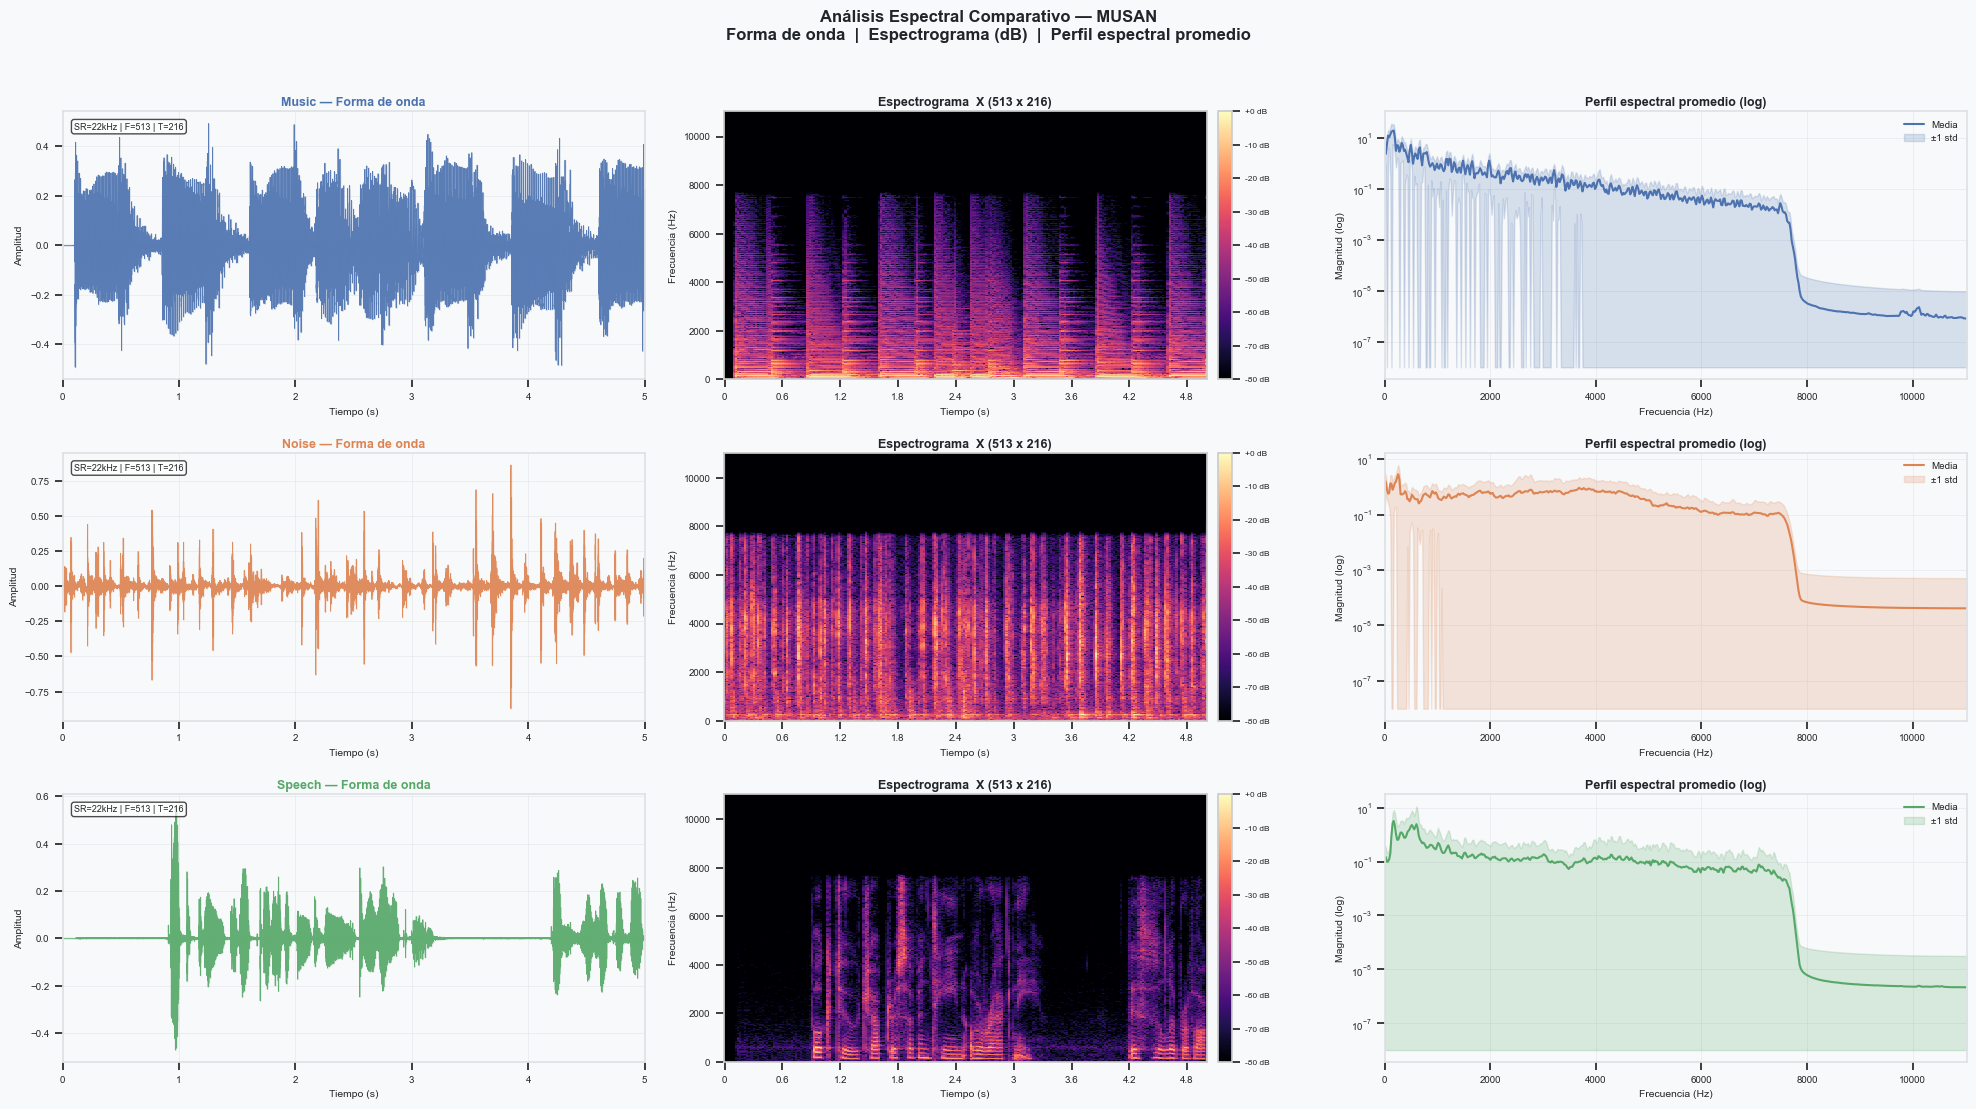

 D:\Optimizacion_proyecto\nmf-audio-separation\outputs/fig2_spectrograms_MUSAN.png


In [12]:
DUR_SHOW = 5.0

fig2, axes = plt.subplots(3, 3, figsize=(20, 11), facecolor=PALETTE['bg'])
fig2.suptitle(
    'Análisis Espectral Comparativo — MUSAN\n'
    'Forma de onda  |  Espectrograma (dB)  |  Perfil espectral promedio',
    fontsize=12, fontweight='bold', y=1.01, color=PALETTE['text']
)

for row_idx, (cat, color, label) in enumerate(zip(cats, colors, labels)):
    path = df_ok[df_ok['category']==cat]['path'].iloc[0]
    y, sr = librosa.load(path, sr=SR_TARGET, mono=True, duration=DUR_SHOW)
    t = np.linspace(0, len(y)/sr, len(y))
    S     = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH)
    S_mag = np.abs(S)
    S_db  = librosa.amplitude_to_db(S_mag, ref=np.max)
    freqs = librosa.fft_frequencies(sr=sr, n_fft=N_FFT)
    F_dim, T_dim = S_mag.shape

    # Col 0: Forma de onda
    ax = axes[row_idx, 0]
    ax.set_facecolor(PALETTE['bg'])
    ax.plot(t, y, color=color, lw=0.6, alpha=0.9)
    ax.fill_between(t, y, 0, color=color, alpha=0.15)
    ax.set_title(f'{label} — Forma de onda', fontsize=9, fontweight='bold', color=color, pad=4)
    ax.set_xlabel('Tiempo (s)', fontsize=7.5); ax.set_ylabel('Amplitud', fontsize=7.5)
    ax.set_xlim(0, DUR_SHOW); ax.tick_params(labelsize=7)
    ax.grid(True, color=PALETTE['grid'], lw=0.5, alpha=0.7)
    for sp in ax.spines.values(): sp.set_edgecolor(PALETTE['grid'])
    ax.text(0.02, 0.96, f'SR={sr//1000}kHz | F={F_dim} | T={T_dim}',
            transform=ax.transAxes, fontsize=6.5, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    # Col 1: Espectrograma dB
    ax = axes[row_idx, 1]
    ax.set_facecolor(PALETTE['bg'])
    img = librosa.display.specshow(S_db, sr=sr, hop_length=HOP_LENGTH,
                                   x_axis='time', y_axis='hz',
                                   cmap='magma', ax=ax, vmin=-80, vmax=0)
    ax.set_title(f'Espectrograma  X ({F_dim} x {T_dim})',
                 fontsize=9, fontweight='bold', pad=4, color=PALETTE['text'])
    ax.set_xlabel('Tiempo (s)', fontsize=7.5); ax.set_ylabel('Frecuencia (Hz)', fontsize=7.5)
    ax.tick_params(labelsize=7)
    fig2.colorbar(img, ax=ax, format='%+2.0f dB', pad=0.02).ax.tick_params(labelsize=6)

    # Col 2: Perfil espectral
    ax = axes[row_idx, 2]
    ax.set_facecolor(PALETTE['bg'])
    mean_s = S_mag.mean(axis=1)
    std_s  = S_mag.std(axis=1)
    ax.semilogy(freqs, mean_s + 1e-8, color=color, lw=1.5, label='Media')
    ax.fill_between(freqs, np.maximum(mean_s-std_s, 1e-8),
                    mean_s+std_s, color=color, alpha=0.20, label='±1 std')
    ax.set_title('Perfil espectral promedio (log)', fontsize=9,
                 fontweight='bold', pad=4, color=PALETTE['text'])
    ax.set_xlabel('Frecuencia (Hz)', fontsize=7.5); ax.set_ylabel('Magnitud (log)', fontsize=7.5)
    ax.set_xlim(0, sr/2); ax.legend(fontsize=7, loc='upper right')
    ax.tick_params(labelsize=7)
    ax.grid(True, color=PALETTE['grid'], lw=0.5, alpha=0.7)
    for sp in ax.spines.values(): sp.set_edgecolor(PALETTE['grid'])

plt.tight_layout()
out2 = f"{OUTPUT_DIR}/fig2_spectrograms_MUSAN.png"
fig2.savefig(out2, dpi=180, bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()
print(f' {out2}')